# Neural Networks
ML LAB 4 

**Yasir Ahmad**  
22MIA1064

## Setup
generate single output dataset

In [1]:
import numpy as np # type: ignore
import tensorflow as tf # type: ignore
from tensorflow.keras.models import Sequential # type: ignore
from tensorflow.keras.layers import Dense # type: ignore
from sklearn.datasets import make_classification, make_moons # type: ignore
import matplotlib.pyplot as plt # type: ignore

# Function to generate linear and non-linear datasets
def generate_datasets():
    # Linear Dataset
    X_linear, y_linear = make_classification(n_samples=1000, n_features=2, n_informative=2, n_redundant=0, 
                                             n_clusters_per_class=1, n_classes=2, random_state=42)
    
    # Non-linear Dataset (moons)
    X_nonlinear, y_nonlinear = make_moons(n_samples=1000, noise=0.2, random_state=42)
    
    return (X_linear, y_linear), (X_nonlinear, y_nonlinear)

# Plotting function to visualize datasets
def plot_datasets(X, y, title):
    plt.scatter(X[:, 0], X[:, 1], c=y, cmap='coolwarm', edgecolor='k')
    plt.title(title)
    plt.show()


## Perceptron

In [2]:
def build_perceptron(activation='sigmoid', use_bias=True):
    # Build a single-layer perceptron model
    model = Sequential([
        Dense(1, activation=activation, input_shape=(2,), use_bias=use_bias)
    ])
    
    # Compile the model
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])  ## optimizer SDG, but slow to converge and not always the best
    
    return model


In [3]:
#viz model
from tensorflow.keras.utils import plot_model #type: ignore

def vis_model(model):
    plot_model(model, to_file="mlp_architecture.png", show_shapes=True, show_layer_names=True, expand_nested=True)
    
    # Display the image if running in a notebook
    from IPython.display import Image # type: ignore
    display(Image(filename='mlp_architecture.png'))


In [4]:
def run_experiment(X, y, activation, use_bias):
    # Build and train the model
    model = build_perceptron(activation=activation, use_bias=use_bias)

    # Visualize model
    #vis_model(model) #gives error in VScode
    
    # Fit the model
    model.fit(X, y, epochs=5, batch_size=1, verbose=1)
    
    # Get the weights and bias
    if use_bias:
        weights, bias = model.layers[0].get_weights()
    else:
        weights = model.layers[0].get_weights()[0]
        bias = None
    print(f'Weights: {weights}')
    print(f'Bias: {bias}')
    
    # Evaluate the model
    loss, accuracy = model.evaluate(X, y, verbose=0)
    print(f'Activation: {activation}, Use Bias: {use_bias}, Accuracy: {accuracy:.2f}')
    return [(activation, use_bias, accuracy),(weights, bias)]


### Main code

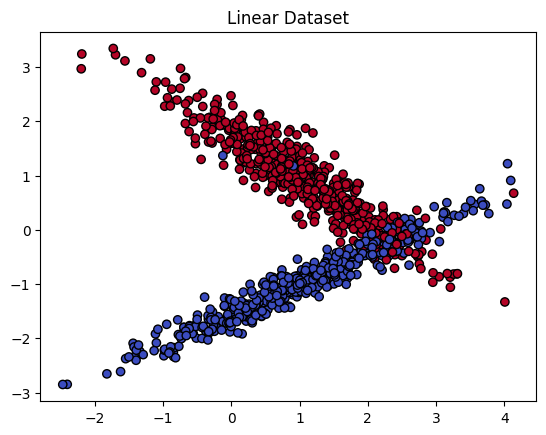

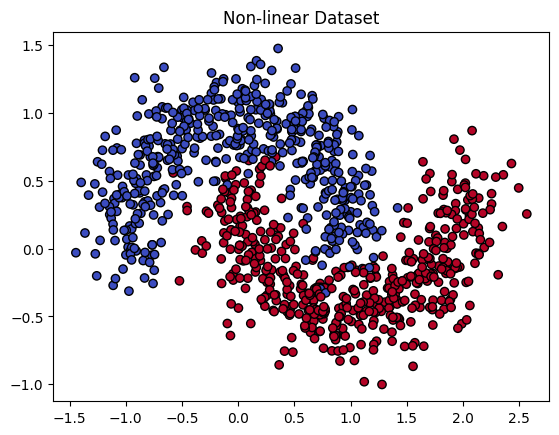

Linear Dataset Results:


Epoch 1/5


1000/1000 [==============================] - 6s 4ms/step - loss: 0.3631 - accuracy: 0.8800
Epoch 2/5
1000/1000 [==============================] - 4s 4ms/step - loss: 0.2998 - accuracy: 0.8980
Epoch 3/5
1000/1000 [==============================] - 2s 2ms/step - loss: 0.2755 - accuracy: 0.8950
Epoch 4/5
1000/1000 [==============================] - 2s 2ms/step - loss: 0.2638 - accuracy: 0.8980
Epoch 5/5
1000/1000 [==============================] - 2s 2ms/step - loss: 0.2578 - accuracy: 0.8950
Weights: [[0.05536489]
 [2.5586166 ]]
Bias: [-0.03654722]
Activation: sigmoid, Use Bias: True, Accuracy: 0.90
Epoch 1/5
1000/1000 [==============================] - 3s 2ms/step - loss: 0.4536 - accuracy: 0.8050
Epoch 2/5
1000/1000 [==============================] - 2s 2ms/step - loss: 0.3323 - accuracy: 0.8710
Epoch 3/5
1000/1000 [==============================] - 3s 3ms/step - loss: 0.2880 - accuracy: 0.8900
Epoch 4/5
1000/1000 [==============================] -

In [5]:
# Generate datasets
(X_linear, y_linear), (X_nonlinear, y_nonlinear) = generate_datasets()

#For metrics
metrics = {"Linear":[],"Non Linear":[]}
params = {"Linear":[],"Non Linear":[]}

# Plot datasets
plot_datasets(X_linear, y_linear, 'Linear Dataset')
plot_datasets(X_nonlinear, y_nonlinear, 'Non-linear Dataset')

# Activation functions to test
activations = ['sigmoid', 'tanh', 'relu']

# Running experiments for linear dataset
print("Linear Dataset Results:")
for activation in activations:
    l1,p1 = run_experiment(X_linear, y_linear, activation, use_bias=True)
    l2,p2 = run_experiment(X_linear, y_linear, activation, use_bias=False)
    metrics["Linear"].append(l1)
    metrics["Linear"].append(l2)
    params["Linear"].append(p1)
    params["Linear"].append(p2)

# Running experiments for non-linear dataset
print("\nNon-linear Dataset Results:")
for activation in activations:
    nl1,np1 = run_experiment(X_nonlinear, y_nonlinear, activation, use_bias=True)
    nl2,np2 = run_experiment(X_nonlinear, y_nonlinear, activation, use_bias=False)
    metrics["Non Linear"].append(nl1)
    metrics["Non Linear"].append(nl2)
    params["Non Linear"].append(np1)
    params["Non Linear"].append(np2)


In [6]:
params['Linear']

[(array([[0.05536489],
         [2.5586166 ]], dtype=float32),
  array([-0.03654722], dtype=float32)),
 (array([[-0.02939343],
         [ 2.49027   ]], dtype=float32),
  None),
 (array([[0.37980926],
         [1.045675  ]], dtype=float32),
  array([0.0001754], dtype=float32)),
 (array([[0.34198877],
         [0.94711226]], dtype=float32),
  None),
 (array([[0.2694393],
         [1.0094167]], dtype=float32),
  array([0.04021159], dtype=float32)),
 (array([[0.17755589],
         [0.82886267]], dtype=float32),
  None)]

### Metrics

In [7]:
metrics

{'Linear': [('sigmoid', True, 0.8980000019073486),
  ('sigmoid', False, 0.8989999890327454),
  ('tanh', True, 0.8859999775886536),
  ('tanh', False, 0.8830000162124634),
  ('relu', True, 0.8870000243186951),
  ('relu', False, 0.8709999918937683)],
 'Non Linear': [('sigmoid', True, 0.8669999837875366),
  ('sigmoid', False, 0.8410000205039978),
  ('tanh', True, 0.37700000405311584),
  ('tanh', False, 0.49000000953674316),
  ('relu', True, 0.3580000102519989),
  ('relu', False, 0.6480000019073486)]}

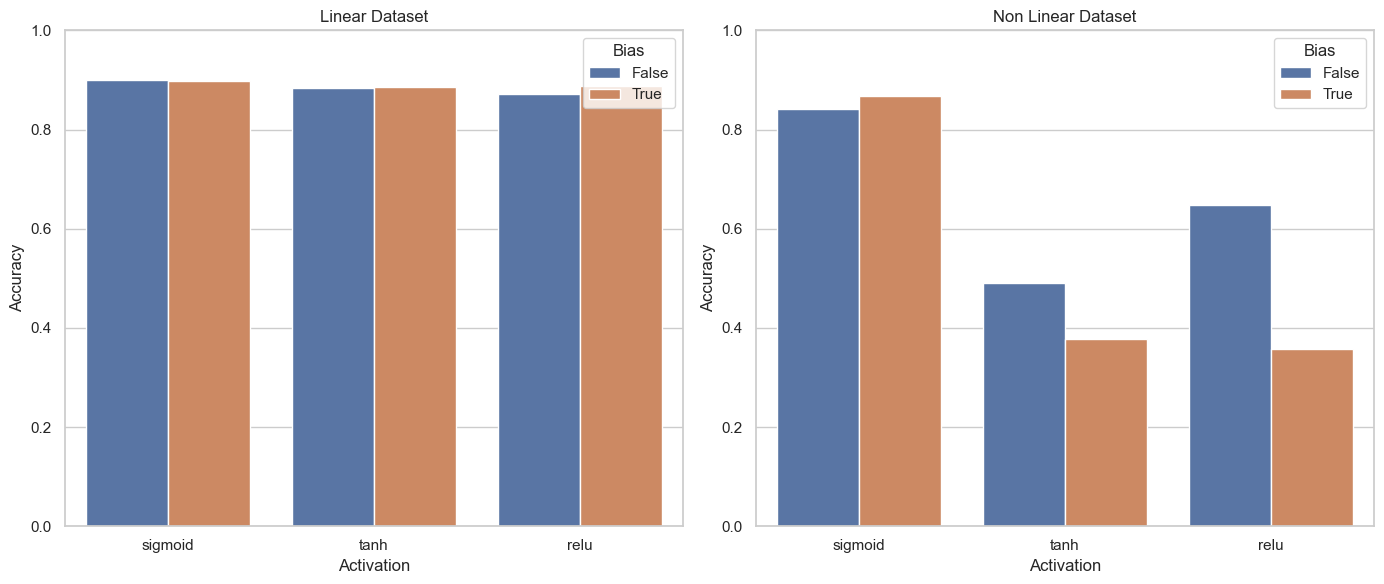

In [8]:
import matplotlib.pyplot as plt # type: ignore
import seaborn as sns # type: ignore 
import pandas as pd # type: ignore

# Dictionary containing activation function accuracies
data = metrics

# Convert data to DataFrame for easier plotting
rows = []
for key in data:
    for activation, bias, accuracy in data[key]:
        rows.append({'Dataset': key, 'Activation': activation, 'Bias': bias, 'Accuracy': accuracy})

df = pd.DataFrame(rows)

# Set the aesthetic style of the plots
sns.set(style="whitegrid")

# Create two bar plots for Linear and Non Linear datasets
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Plot for Linear dataset
sns.barplot(x='Activation', y='Accuracy', hue='Bias', data=df[df['Dataset'] == 'Linear'], ax=axes[0])
axes[0].set_title('Linear Dataset')
axes[0].set_ylim(0, 1)
axes[0].legend(title='Bias')

# Plot for Non Linear dataset
sns.barplot(x='Activation', y='Accuracy', hue='Bias', data=df[df['Dataset'] == 'Non Linear'], ax=axes[1])
axes[1].set_title('Non Linear Dataset')
axes[1].set_ylim(0, 1)
axes[1].legend(title='Bias')

# Show plots
plt.tight_layout()
plt.show()


## Backpropagation

In [9]:
def build_perceptron(activation='sigmoid', use_bias=True):
    # Build a single-layer perceptron model
    model = Sequential([
        Dense(1, activation=activation, input_shape=(2,), use_bias=use_bias)
    ])
    
    # Compile the model
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    
    return model
def run_experiment(X, y, activation, use_bias):
    # Build and train the model
    model = build_perceptron(activation=activation, use_bias=use_bias)
    model.fit(X, y, epochs=10, batch_size=1000, verbose=1)
    
    # Evaluate the model
    loss, accuracy = model.evaluate(X, y, verbose=0)
    print(f'Activation: {activation}, Use Bias: {use_bias}, Accuracy: {accuracy:.2f}')
    return (activation,use_bias,accuracy)

### Main Code

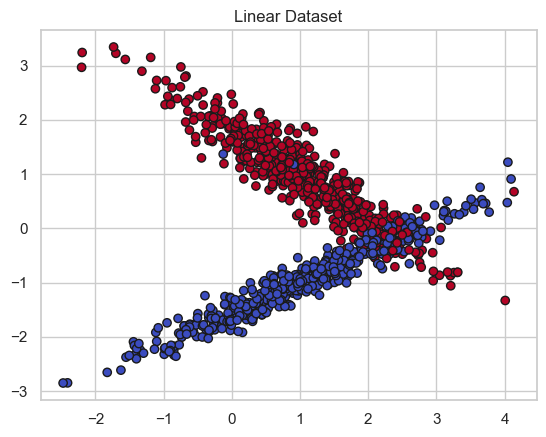

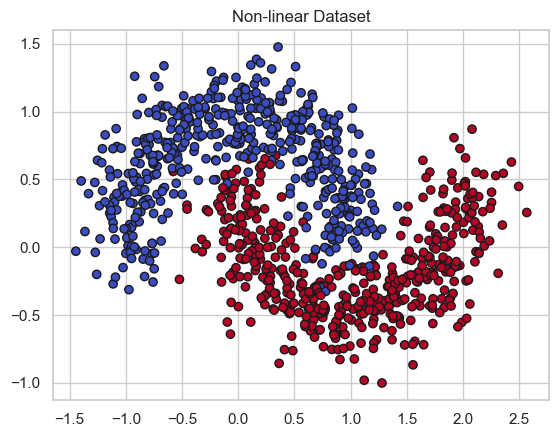

Linear Dataset Results:
Epoch 1/10
1/1 [==============================] - 1s 1s/step - loss: 0.8496 - accuracy: 0.2780
Epoch 2/10
1/1 [==============================] - 0s 12ms/step - loss: 0.8488 - accuracy: 0.2780
Epoch 3/10
1/1 [==============================] - 0s 11ms/step - loss: 0.8480 - accuracy: 0.2770
Epoch 4/10
1/1 [==============================] - 0s 11ms/step - loss: 0.8472 - accuracy: 0.2750
Epoch 5/10
1/1 [==============================] - 0s 16ms/step - loss: 0.8464 - accuracy: 0.2750
Epoch 6/10
1/1 [==============================] - 0s 10ms/step - loss: 0.8456 - accuracy: 0.2750
Epoch 7/10
1/1 [==============================] - 0s 52ms/step - loss: 0.8448 - accuracy: 0.2750
Epoch 8/10
1/1 [==============================] - 0s 46ms/step - loss: 0.8440 - accuracy: 0.2740
Epoch 9/10
1/1 [==============================] - 0s 17ms/step - loss: 0.8432 - accuracy: 0.2740
Epoch 10/10
1/1 [==============================] - 0s 15ms/step - loss: 0.8424 - accuracy: 0.2740
Activat

In [10]:
# Generate datasets
(X_linear, y_linear), (X_nonlinear, y_nonlinear) = generate_datasets()

#For metrics
metrics = {"Linear":[],"Non Linear":[]}

# Plot datasets
plot_datasets(X_linear, y_linear, 'Linear Dataset')
plot_datasets(X_nonlinear, y_nonlinear, 'Non-linear Dataset')

# Activation functions to test
activations = ['sigmoid', 'tanh', 'relu']

# Running experiments for linear dataset
print("Linear Dataset Results:")
for activation in activations:
    l1 = run_experiment(X_linear, y_linear, activation, use_bias=True)
    l2 = run_experiment(X_linear, y_linear, activation, use_bias=False)
    metrics["Linear"].append(l1)
    metrics["Linear"].append(l2)

# Running experiments for non-linear dataset
print("\nNon-linear Dataset Results:")
for activation in activations:
    nl1 = run_experiment(X_nonlinear, y_nonlinear, activation, use_bias=True)
    nl2 = run_experiment(X_nonlinear, y_nonlinear, activation, use_bias=False)
    metrics["Non Linear"].append(nl1)
    metrics["Non Linear"].append(nl2)


### Metrics

In [11]:
metrics

{'Linear': [('sigmoid', True, 0.27399998903274536),
  ('sigmoid', False, 0.7509999871253967),
  ('tanh', True, 0.2199999988079071),
  ('tanh', False, 0.6050000190734863),
  ('relu', True, 0.8529999852180481),
  ('relu', False, 0.574999988079071)],
 'Non Linear': [('sigmoid', True, 0.14499999582767487),
  ('sigmoid', False, 0.7870000004768372),
  ('tanh', True, 0.7390000224113464),
  ('tanh', False, 0.29600000381469727),
  ('relu', True, 0.8090000152587891),
  ('relu', False, 0.6800000071525574)]}

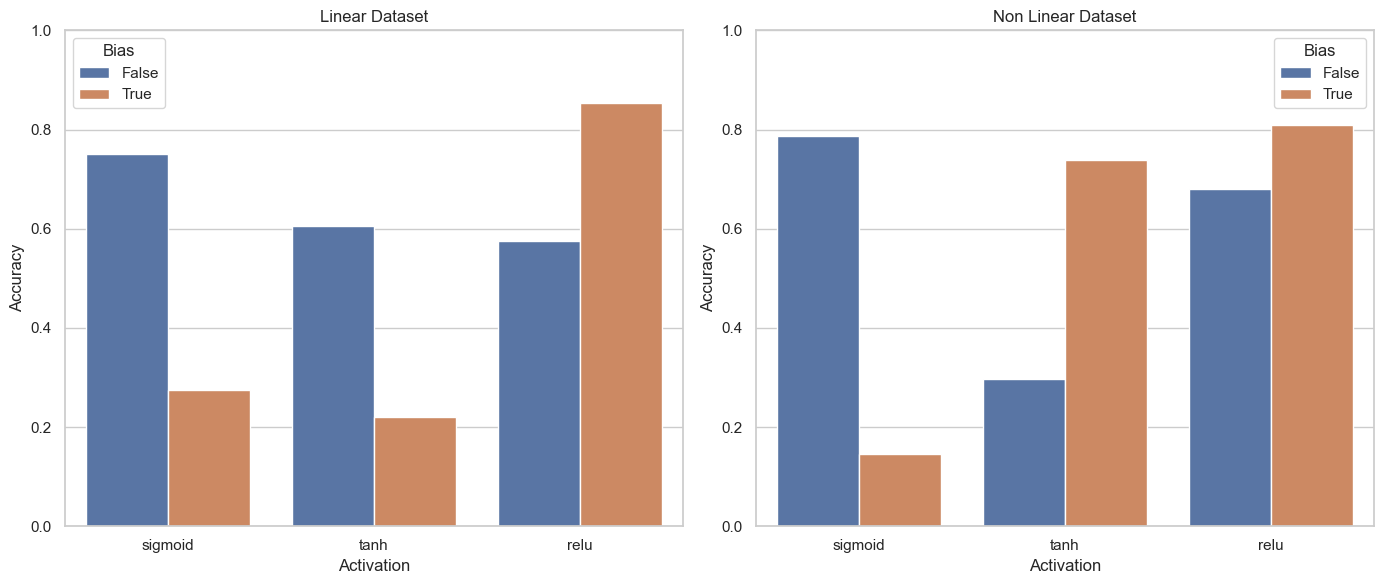

In [12]:
import matplotlib.pyplot as plt # type: ignore
import seaborn as sns # type: ignore 
import pandas as pd # type: ignore

# Dictionary containing activation function accuracies
data = metrics

# Convert data to DataFrame for easier plotting
rows = []
for key in data:
    for activation, bias, accuracy in data[key]:
        rows.append({'Dataset': key, 'Activation': activation, 'Bias': bias, 'Accuracy': accuracy})

df = pd.DataFrame(rows)

# Set the aesthetic style of the plots
sns.set(style="whitegrid")

# Create two bar plots for Linear and Non Linear datasets
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Plot for Linear dataset
sns.barplot(x='Activation', y='Accuracy', hue='Bias', data=df[df['Dataset'] == 'Linear'], ax=axes[0])
axes[0].set_title('Linear Dataset')
axes[0].set_ylim(0, 1)
axes[0].legend(title='Bias')

# Plot for Non Linear dataset
sns.barplot(x='Activation', y='Accuracy', hue='Bias', data=df[df['Dataset'] == 'Non Linear'], ax=axes[1])
axes[1].set_title('Non Linear Dataset')
axes[1].set_ylim(0, 1)
axes[1].legend(title='Bias')

# Show plots
plt.tight_layout()
plt.show()


## Multilayer perceptron

In [13]:
def build_mlp(activation='sigmoid', use_bias=True):
    # Build a single-layer perceptron model
    model = Sequential([
        Dense(2, activation=activation, input_shape=(2,), use_bias=use_bias),
        Dense(3, activation=activation, use_bias=use_bias),
        Dense(1, activation=activation, use_bias=use_bias)
    ])
    
    # Compile the model
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    
    return model


In [14]:
def run_experiment(X, y, activation, use_bias):
    # Build and train the model
    model = build_mlp(activation=activation, use_bias=use_bias)

    # Visualize model
    #vis_model(model) #gives error in VScode
    
    # Fit the model
    model.fit(X, y, epochs=10, batch_size=1, verbose=1)
    
    # Get the weights and bias
    if use_bias:
        weights, bias = model.layers[0].get_weights()
    else:
        weights = model.layers[0].get_weights()[0]
        bias = None
    print(f'Weights: {weights}')
    print(f'Bias: {bias}')
    
    # Evaluate the model
    loss, accuracy = model.evaluate(X, y, verbose=0)
    print(f'Activation: {activation}, Use Bias: {use_bias}, Accuracy: {accuracy:.2f}')
    return [(activation, use_bias, accuracy),(weights, bias)]


### Main Code

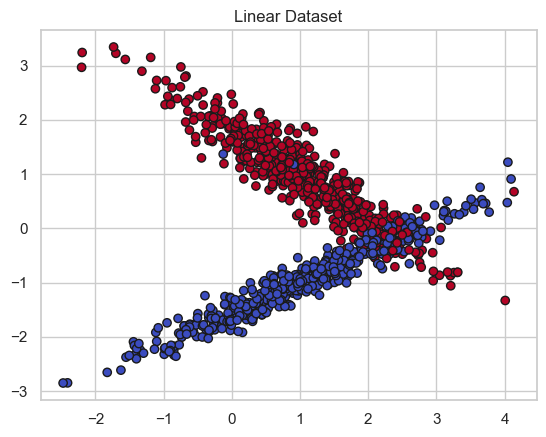

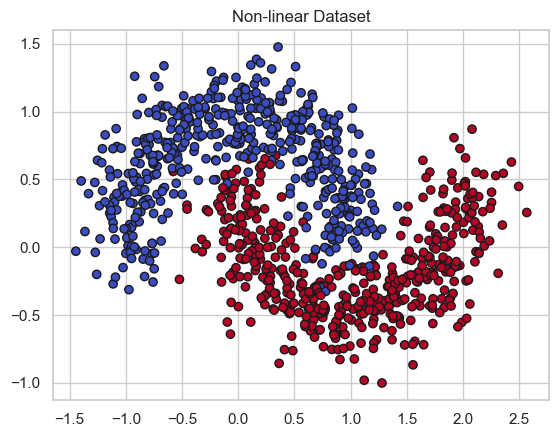

Linear Dataset Results:
Epoch 1/10
1000/1000 [==============================] - 5s 3ms/step - loss: 0.6821 - accuracy: 0.5010
Epoch 2/10
1000/1000 [==============================] - 3s 3ms/step - loss: 0.5857 - accuracy: 0.7260
Epoch 3/10
1000/1000 [==============================] - 3s 3ms/step - loss: 0.4972 - accuracy: 0.8810
Epoch 4/10
1000/1000 [==============================] - 3s 3ms/step - loss: 0.4239 - accuracy: 0.8840
Epoch 5/10
1000/1000 [==============================] - 3s 3ms/step - loss: 0.3715 - accuracy: 0.8860
Epoch 6/10
1000/1000 [==============================] - 3s 3ms/step - loss: 0.3376 - accuracy: 0.8850
Epoch 7/10
1000/1000 [==============================] - 3s 3ms/step - loss: 0.3170 - accuracy: 0.8860
Epoch 8/10
1000/1000 [==============================] - 3s 3ms/step - loss: 0.3047 - accuracy: 0.8860
Epoch 9/10
1000/1000 [==============================] - 3s 3ms/step - loss: 0.2965 - accuracy: 0.8860
Epoch 10/10
1000/1000 [==============================] - 3

In [15]:
# Generate datasets
(X_linear, y_linear), (X_nonlinear, y_nonlinear) = generate_datasets()

#For metrics
metrics = {"Linear":[],"Non Linear":[]}
params = {"Linear":[],"Non Linear":[]}

# Plot datasets
plot_datasets(X_linear, y_linear, 'Linear Dataset')
plot_datasets(X_nonlinear, y_nonlinear, 'Non-linear Dataset')

# Activation functions to test
activations = ['sigmoid', 'tanh', 'relu']

# Running experiments for linear dataset
print("Linear Dataset Results:")
for activation in activations:
    l1,p1 = run_experiment(X_linear, y_linear, activation, use_bias=True)
    l2,p2 = run_experiment(X_linear, y_linear, activation, use_bias=False)
    metrics["Linear"].append(l1)
    metrics["Linear"].append(l2)
    params["Linear"].append(p1)
    params["Linear"].append(p2)

# Running experiments for non-linear dataset
print("\nNon-linear Dataset Results:")
for activation in activations:
    nl1,np1 = run_experiment(X_nonlinear, y_nonlinear, activation, use_bias=True)
    nl2,np2 = run_experiment(X_nonlinear, y_nonlinear, activation, use_bias=False)
    metrics["Non Linear"].append(nl1)
    metrics["Non Linear"].append(nl2)
    params["Non Linear"].append(np1)
    params["Non Linear"].append(np2)


In [16]:
metrics

{'Linear': [('sigmoid', True, 0.8899999856948853),
  ('sigmoid', False, 0.8899999856948853),
  ('tanh', True, 0.9079999923706055),
  ('tanh', False, 0.8799999952316284),
  ('relu', True, 0.902999997138977),
  ('relu', False, 0.8669999837875366)],
 'Non Linear': [('sigmoid', True, 0.8669999837875366),
  ('sigmoid', False, 0.8669999837875366),
  ('tanh', True, 0.8500000238418579),
  ('tanh', False, 0.7170000076293945),
  ('relu', True, 0.8619999885559082),
  ('relu', False, 0.8190000057220459)]}

In [17]:
params

{'Linear': [(array([[-0.40217507, -0.77611136],
          [-3.3975961 , -3.2261982 ]], dtype=float32),
   array([0.06139571, 0.04907172], dtype=float32)),
  (array([[-0.91478884, -0.7119787 ],
          [-4.2990127 , -3.7599196 ]], dtype=float32),
   None),
  (array([[ 0.48993307,  0.40679422],
          [-1.3207946 ,  0.1825409 ]], dtype=float32),
   array([-0.2179616 ,  0.09906753], dtype=float32)),
  (array([[0.5507891 , 0.28497323],
          [1.2076056 , 1.1607227 ]], dtype=float32),
   None),
  (array([[ 0.10296278,  0.27351287],
          [ 0.6781643 , -0.39635938]], dtype=float32),
   array([ 0.42966026, -0.08449332], dtype=float32)),
  (array([[-0.43107694,  0.06443495],
          [ 0.34512207,  0.69565976]], dtype=float32),
   None)],
 'Non Linear': [(array([[ 1.3864626 ,  0.93793845],
          [-4.0790215 , -3.407654  ]], dtype=float32),
   array([-0.36570764, -0.17095003], dtype=float32)),
  (array([[ 1.2852863, -1.0966903],
          [-4.0098977,  4.1763277]], dtype=float

### Metrics

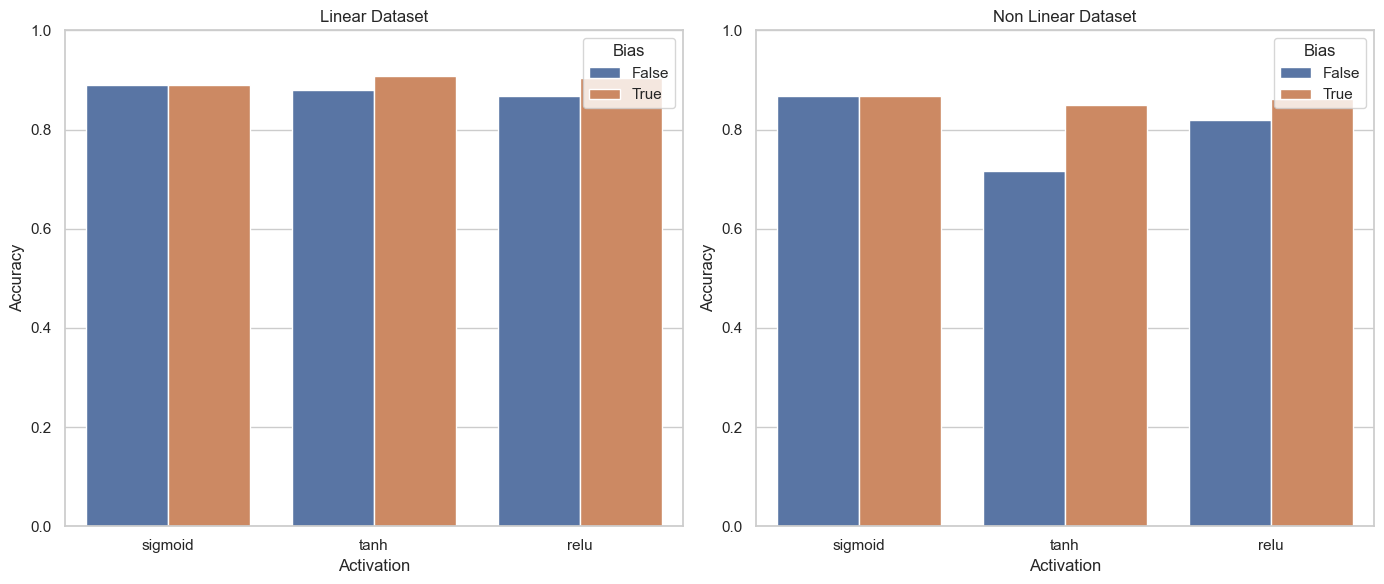

In [18]:
import matplotlib.pyplot as plt # type: ignore
import seaborn as sns # type: ignore 
import pandas as pd # type: ignore

# Dictionary containing activation function accuracies
data = metrics

# Convert data to DataFrame for easier plotting
rows = []
for key in data:
    for activation, bias, accuracy in data[key]:
        rows.append({'Dataset': key, 'Activation': activation, 'Bias': bias, 'Accuracy': accuracy})

df = pd.DataFrame(rows)

# Set the aesthetic style of the plots
sns.set(style="whitegrid")

# Create two bar plots for Linear and Non Linear datasets
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Plot for Linear dataset
sns.barplot(x='Activation', y='Accuracy', hue='Bias', data=df[df['Dataset'] == 'Linear'], ax=axes[0])
axes[0].set_title('Linear Dataset')
axes[0].set_ylim(0, 1)
axes[0].legend(title='Bias')

# Plot for Non Linear dataset
sns.barplot(x='Activation', y='Accuracy', hue='Bias', data=df[df['Dataset'] == 'Non Linear'], ax=axes[1])
axes[1].set_title('Non Linear Dataset')
axes[1].set_ylim(0, 1)
axes[1].legend(title='Bias')

# Show plots
plt.tight_layout()
plt.show()


## Multiple outputs MLP

In [19]:
import numpy as np # type: ignore
import tensorflow as tf # type: ignore
from tensorflow.keras.models import Sequential # type: ignore
from tensorflow.keras.layers import Dense # type: ignore
from sklearn.datasets import make_classification, make_moons # type: ignore
import matplotlib.pyplot as plt # type: ignore

# Function to generate linear and non-linear datasets
def generate_datasets():
    # Linear Dataset
    X_linear, y_linear = make_classification(n_samples=1000, n_features=2, n_informative=2, n_redundant=0, 
                                             n_clusters_per_class=1, n_classes=3, random_state=42)
    
        
    return (X_linear, y_linear), (X_nonlinear, y_nonlinear)

# Plotting function to visualize datasets
def plot_datasets(X, y, title):
    plt.scatter(X[:, 0], X[:, 1], c=y, cmap='coolwarm', edgecolor='k')
    plt.title(title)
    plt.show()


In [20]:
def build_mlp(activation='sigmoid', use_bias=True):
    # Build a single-layer perceptron model
    model = Sequential([
        Dense(2, activation=activation, input_shape=(2,), use_bias=use_bias),
        Dense(3, activation=activation, use_bias=use_bias),
        Dense(3, activation="softmax", use_bias=use_bias)
    ])
    
    # Compile the model
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    
    return model


In [21]:
def run_experiment(X, y, activation, use_bias):
    # Build and train the model
    model = build_mlp(activation=activation, use_bias=use_bias)

    # Visualize model
    #vis_model(model) #gives error in VScode
    
    # Fit the model
    model.fit(X, y, epochs=10, batch_size=1, verbose=1)
    
    # Get the weights and bias
    if use_bias:
        weights, bias = model.layers[0].get_weights()
    else:
        weights = model.layers[0].get_weights()[0]
        bias = None
    print(f'Weights: {weights}')
    print(f'Bias: {bias}')
    
    # Evaluate the model
    loss, accuracy = model.evaluate(X, y, verbose=0)
    print(f'Activation: {activation}, Use Bias: {use_bias}, Accuracy: {accuracy:.2f}')
    return [(activation, use_bias, accuracy),(weights, bias)]


C:\Users\YasirAhmd\AppData\Local\Temp\ipykernel_15560\276242794.py:19: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  plt.scatter(X[:, 0], X[:, 1], c=y, cmap='coolwarm', edgecolor='k')


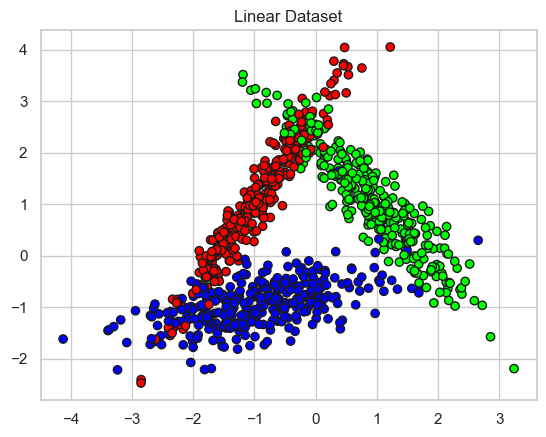

Linear Dataset Results:
Epoch 1/10
1000/1000 [==============================] - 5s 3ms/step - loss: 1.1009 - accuracy: 0.3060
Epoch 2/10
1000/1000 [==============================] - 3s 3ms/step - loss: 1.0735 - accuracy: 0.5140
Epoch 3/10
1000/1000 [==============================] - 3s 3ms/step - loss: 1.0151 - accuracy: 0.6450
Epoch 4/10
1000/1000 [==============================] - 3s 3ms/step - loss: 0.9208 - accuracy: 0.6610
Epoch 5/10
1000/1000 [==============================] - 3s 3ms/step - loss: 0.8250 - accuracy: 0.6720
Epoch 6/10
1000/1000 [==============================] - 3s 3ms/step - loss: 0.7550 - accuracy: 0.6710
Epoch 7/10
1000/1000 [==============================] - 3s 3ms/step - loss: 0.7083 - accuracy: 0.6840
Epoch 8/10
1000/1000 [==============================] - 3s 3ms/step - loss: 0.6751 - accuracy: 0.7000
Epoch 9/10
1000/1000 [==============================] - 3s 3ms/step - loss: 0.6476 - accuracy: 0.7290
Epoch 10/10
1000/1000 [==============================] - 3

In [22]:
# Generate datasets
(X_linear, y_linear), (X_nonlinear, y_nonlinear) = generate_datasets()

# Convert target variable to one-hot encoding
y_linear = tf.keras.utils.to_categorical(y_linear)

#For metrics
metrics = {"Linear":[]}
params = {"Linear":[]}

# Plot datasets
plot_datasets(X_linear, y_linear, 'Linear Dataset')

# Activation functions to test
activations = ['sigmoid', 'tanh', 'relu']

# Running experiments for linear dataset
print("Linear Dataset Results:")
for activation in activations:
    l1,p1 = run_experiment(X_linear, y_linear, activation, use_bias=True)
    l2,p2 = run_experiment(X_linear, y_linear, activation, use_bias=False)
    metrics["Linear"].append(l1)
    metrics["Linear"].append(l2)
    params["Linear"].append(p1)
    params["Linear"].append(p2)



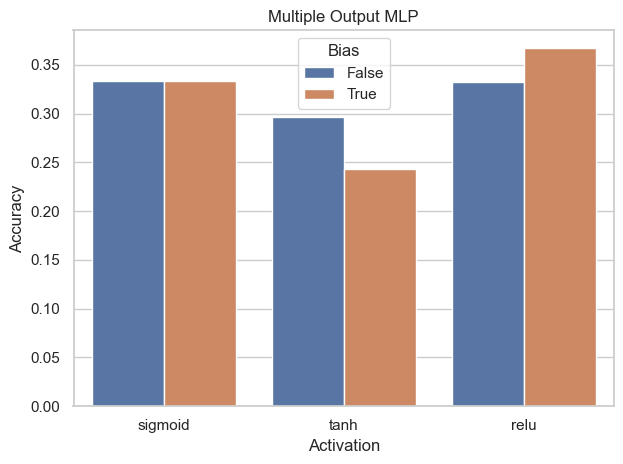

In [29]:
import matplotlib.pyplot as plt # type: ignore
import seaborn as sns # type: ignore 
import pandas as pd # type: ignore

# Dictionary containing activation function accuracies
data = metrics

# Convert data to DataFrame for easier plotting
rows = []
for key in data:
    for activation, bias, accuracy in data[key]:
        rows.append({'Dataset': key, 'Activation': activation, 'Bias': bias, 'Accuracy': accuracy})

df = pd.DataFrame(rows)

# Set the aesthetic style of the plots
sns.set(style="whitegrid")

# Create two bar plots for Linear and Non Linear datasets
#fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Plot for Linear Multiple Output dataset
sns.barplot(x='Activation', y='Accuracy', hue='Bias', data=df[df['Dataset'] == 'Linear'])
plt.title('Multiple Output MLP')
plt.legend(title='Bias')

# Show plots
plt.tight_layout()
plt.show()


## Multiple Output Backprop

In [24]:
def build_mlp(activation='sigmoid', use_bias=True):
    # Build a single-layer perceptron model
    model = Sequential([
        Dense(2, activation=activation, input_shape=(2,), use_bias=use_bias),
        Dense(3, activation=activation, use_bias=use_bias),
        Dense(3, activation="softmax", use_bias=use_bias)
    ])
    
    # Compile the model
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    
    return model


In [25]:
def run_experiment(X, y, activation, use_bias):
    # Build and train the model
    model = build_mlp(activation=activation, use_bias=use_bias)

    # Visualize model
    #vis_model(model) #gives error in VScode
    
    # Fit the model
    model.fit(X, y, epochs=10, batch_size=1000, verbose=1)
    
    # Get the weights and bias
    if use_bias:
        weights, bias = model.layers[0].get_weights()
    else:
        weights = model.layers[0].get_weights()[0]
        bias = None
    print(f'Weights: {weights}')
    print(f'Bias: {bias}')
    
    # Evaluate the model
    loss, accuracy = model.evaluate(X, y, verbose=0)
    print(f'Activation: {activation}, Use Bias: {use_bias}, Accuracy: {accuracy:.2f}')
    return [(activation, use_bias, accuracy),(weights, bias)]


C:\Users\YasirAhmd\AppData\Local\Temp\ipykernel_15560\276242794.py:19: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  plt.scatter(X[:, 0], X[:, 1], c=y, cmap='coolwarm', edgecolor='k')


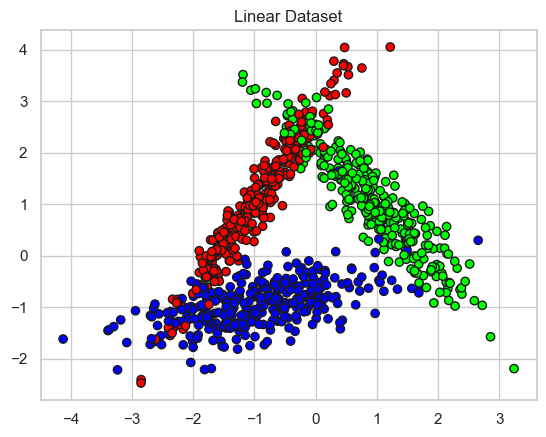

Linear Dataset Results:
Epoch 1/10
1/1 [==============================] - 2s 2s/step - loss: 1.1638 - accuracy: 0.3330
Epoch 2/10
1/1 [==============================] - 0s 13ms/step - loss: 1.1626 - accuracy: 0.3330
Epoch 3/10
1/1 [==============================] - 0s 17ms/step - loss: 1.1614 - accuracy: 0.3330
Epoch 4/10
1/1 [==============================] - 0s 14ms/step - loss: 1.1603 - accuracy: 0.3330
Epoch 5/10
1/1 [==============================] - 0s 14ms/step - loss: 1.1591 - accuracy: 0.3330
Epoch 6/10
1/1 [==============================] - 0s 17ms/step - loss: 1.1580 - accuracy: 0.3330
Epoch 7/10
1/1 [==============================] - 0s 17ms/step - loss: 1.1569 - accuracy: 0.3330
Epoch 8/10
1/1 [==============================] - 0s 17ms/step - loss: 1.1558 - accuracy: 0.3330
Epoch 9/10
1/1 [==============================] - 0s 14ms/step - loss: 1.1547 - accuracy: 0.3330
Epoch 10/10
1/1 [==============================] - 0s 12ms/step - loss: 1.1536 - accuracy: 0.3330
Weights

In [26]:
# Generate datasets
(X_linear, y_linear), (X_nonlinear, y_nonlinear) = generate_datasets()

# Convert target variable to one-hot encoding
y_linear = tf.keras.utils.to_categorical(y_linear)

#For metrics
metrics = {"Linear":[]}
params = {"Linear":[]}

# Plot datasets
plot_datasets(X_linear, y_linear, 'Linear Dataset')

# Activation functions to test
activations = ['sigmoid', 'tanh', 'relu']

# Running experiments for linear dataset
print("Linear Dataset Results:")
for activation in activations:
    l1,p1 = run_experiment(X_linear, y_linear, activation, use_bias=True)
    l2,p2 = run_experiment(X_linear, y_linear, activation, use_bias=False)
    metrics["Linear"].append(l1)
    metrics["Linear"].append(l2)
    params["Linear"].append(p1)
    params["Linear"].append(p2)



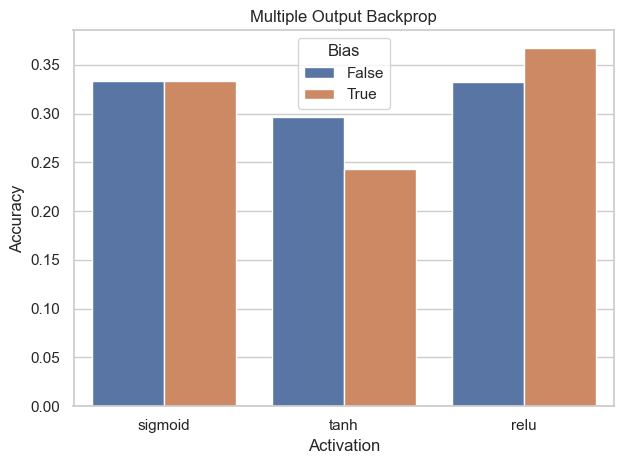

In [28]:
import matplotlib.pyplot as plt # type: ignore
import seaborn as sns # type: ignore 
import pandas as pd # type: ignore

# Dictionary containing activation function accuracies
data = metrics

# Convert data to DataFrame for easier plotting
rows = []
for key in data:
    for activation, bias, accuracy in data[key]:
        rows.append({'Dataset': key, 'Activation': activation, 'Bias': bias, 'Accuracy': accuracy})

df = pd.DataFrame(rows)

# Set the aesthetic style of the plots
sns.set(style="whitegrid")

# Create two bar plots for Linear and Non Linear datasets
#fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Plot for Linear Multiple Output dataset
sns.barplot(x='Activation', y='Accuracy', hue='Bias', data=df[df['Dataset'] == 'Linear'])
plt.title('Multiple Output Backprop')
plt.legend(title='Bias')

# Show plots
plt.tight_layout()
plt.show()
